# Demand exploratory data analysis

This notebook investigates local simulated supply-chain demand at **Date + SKU_ID + Warehouse_ID**, using **Units_Sold**. Its saved tables and inline figures support direct review without rerunning. All detailed CSV outputs stay in ignored `data/processed/demand_eda/`; report figures are also saved under `reports/figures/demand-eda/`.

## Context and methods

No forecasting models, final features, split dates or seasonal regimes are created. The source `Demand_Forecast` is checked only as dataset-quality metadata, then excluded from demand analysis. Promotion comparisons are descriptive; no causal or Sri Lankan holiday effects are inferred.

**References:** [dataset contract](../../docs/dataset.md), [research design](../../docs/research-design.md), [DR-002](../../docs/decisions/DR-002-forecasting-analytical-unit.md), [DR-003](../../docs/decisions/DR-003-forecasting-feature-engineering-baseline.md), [DR-004](../../docs/decisions/DR-004-forecast-horizons.md), and [prior profile](../../reports/temporal-demand-profile.md).

### Assumptions and setup

The date column represents a calendar day. Counts are integral/nonnegative; costs and prices are nonnegative; flags are binary. Historical min/max values are descriptive, not new business bounds. Failed checks block analysis rather than silently repairing data. Completeness uses the global observed span plus a comparison with documented endpoints and cardinalities.

From the repository root install `requirements-dev.txt` into `.venv`. Select that Python environment when opening this notebook. The report contains an exact `nbclient` execution command. Changing the input requires reviewing any baseline discrepancies before continuing.

> **Historical EDA provenance — notice added 2026-09-29:** The descriptive results and original methodology wording below are preserved from the earlier research stage; they do not define the current feature set, horizons or experiment authority. References to 1/7/14-day horizons, an unselected lag set or an untouched holdout are historical. The current [frozen feature contract](../../docs/forecasting-feature-engineering.md) and [methodology/provenance record](../../docs/forecasting-methodology-revision.md) govern forecasting. Final evaluation is December 3–30, 2024, origin December 2, reserved from subsequent selection/fitting but not fully unseen historically: December 3–16 had prior validation exposure and full-year EDA inspected the interval. No results were regenerated or tests/experiments executed for this notice.


In [17]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/data/demand_eda.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data.demand_eda import (
    validate_data, require_valid, analyze_demand, make_figures,
    save_tables, source_receipt, interpretations, build_report,
)
INPUT = ROOT / "data/raw/supply_chain_dataset1.csv"
LOCAL = ROOT / "data/processed/demand_eda"
FIGURES = ROOT / "reports/figures/demand-eda"
pd.set_option("display.max_columns", 16)
pd.set_option("display.max_rows", 55)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Data and provenance

The source is read directly on every run. The hash identifies the exact local file used; no raw-record preview is embedded in this notebook.

In [18]:
receipt = source_receipt(INPUT)
display(receipt)
raw = pd.read_csv(INPUT)
df, audit = validate_data(raw)
save_tables({**audit, "source_receipt": receipt}, LOCAL)
display(audit["baseline"])
display(audit["native_grain"])

,item,value
0,source_file,supply_chain_dataset1.csv
1,sha256,76dad280541a60f135442f3eeb3ef4804a28e48f6a9677...
2,bytes,6552486
3,pandas,3.0.6
4,numpy,2.5.3


,check,documented,observed,matches
0,rows,91250,91250,True
1,columns,15,15,True
2,dates,365,365,True
3,skus,50,50,True
4,warehouses,5,5,True
5,date_min,2024-01-01,2024-01-01,True
6,date_max,2024-12-30,2024-12-30,True
7,suppliers,10,10,True
8,regions,4,4,True
9,stockout_zero_rows,91250,91250,True


,check,value,note
0,source_rows,91250,Total source records
1,unique_date_sku_warehouse_keys,91250,Distinct Date + SKU_ID + Warehouse_ID combinat...
2,duplicate_rows_at_native_key,0,Rows participating in duplicated native keys
3,native_key_is_unique,True,Whether the source grain is one row per Date +...


### Validation and cleaning audit

`affected` counts cells or records as named; counts across checks can overlap and must not be added as a total number of invalid rows. Duplicate-key rows include every participating row. The exact-duplicate count measures extra repeated rows.

In [19]:
display(audit["validation"])
display(audit["missingness"])
display(audit["numeric_ranges"])
require_valid(audit)
if not audit["baseline"]["matches"].all():
    raise ValueError("Source differs from documented baseline: review and report the contradiction before proceeding.")
display(Markdown("**All checks passed.** Parsing and sorting preserve every source observation. No imputation, clipping, duplicate aggregation, or row deletion was applied."))

,check,affected
0,missing_cells,0
1,blank_cells,0
2,invalid_dates,0
3,non_midnight_dates,0
4,SKU_ID_surrounding_whitespace,0
5,Warehouse_ID_surrounding_whitespace,0
6,Supplier_ID_surrounding_whitespace,0
7,Region_surrounding_whitespace,0
8,Units_Sold_invalid_numeric,0
9,Units_Sold_infinite,0


,column,missing,blank
0,Date,0,0
1,SKU_ID,0,0
2,Warehouse_ID,0,0
3,Supplier_ID,0,0
4,Region,0,0
5,Units_Sold,0,0
6,Inventory_Level,0,0
7,Supplier_Lead_Time_Days,0,0
8,Reorder_Point,0,0
9,Order_Quantity,0,0


,column,min,max,mean,median
0,Units_Sold,0.0000,59.0000,20.0546,20.0000
1,Inventory_Level,168.0000,990.0000,471.5223,461.0000
2,Supplier_Lead_Time_Days,2.0000,14.0000,7.9840,8.0000
3,Reorder_Point,201.0000,398.0000,300.0680,300.0000
4,Order_Quantity,0.0000,499.0000,19.2725,0.0000
5,Unit_Cost,5.0200,19.7600,12.2033,11.9900
6,Unit_Price,6.9500,35.1000,18.2618,18.1800
7,Promotion_Flag,0.0000,1.0000,0.1016,0.0000
8,Stockout_Flag,0.0000,0.0000,0.0000,0.0000
9,Demand_Forecast,0.0000,61.4200,20.0820,19.9500


**All checks passed.** Parsing and sorting preserve every source observation. No imputation, clipping, duplicate aggregation, or row deletion was applied.

### Temporal completeness and zero demand

Coverage is checked against every date in the global observed span for the Cartesian product of observed SKU and warehouse identifiers. This catches missing series at a warehouse and missing days at a series boundary. The baseline check separately guards against a missing entity or a shortened overall span.

In [20]:
display(audit["coverage"].groupby(["observed_days", "expected_days_in_observed_span", "missing_days", "completeness"]).size().reset_index(name="series_count"))
display(audit["coverage"].head(10))
calendar = pd.DataFrame({
    "measure": ["First observed day", "Last observed day", "Observed dates", "Dates in calendar year", "Native rows per day: min", "Native rows per day: max", "Zero-demand rows", "Zero-demand share"],
    "value": [str(df.Date.min().date()), str(df.Date.max().date()), df.Date.nunique(),
              len(pd.date_range(f"{df.Date.min().year}-01-01", f"{df.Date.min().year}-12-31")),
              df.groupby("Date").size().min(), df.groupby("Date").size().max(),
              df.Units_Sold.eq(0).sum(), df.Units_Sold.eq(0).mean()],
})
display(calendar)
save_tables({"calendar_and_zero_demand": calendar}, LOCAL)

,observed_days,expected_days_in_observed_span,missing_days,completeness,series_count
0,365,365,0,1.0000,250


,SKU_ID,Warehouse_ID,observed_days,expected_days_in_observed_span,missing_days,completeness
0,SKU_1,WH_1,365,365,0,1.0000
1,SKU_1,WH_2,365,365,0,1.0000
2,SKU_1,WH_3,365,365,0,1.0000
3,SKU_1,WH_4,365,365,0,1.0000
4,SKU_1,WH_5,365,365,0,1.0000
5,SKU_10,WH_1,365,365,0,1.0000
6,SKU_10,WH_2,365,365,0,1.0000
7,SKU_10,WH_3,365,365,0,1.0000
8,SKU_10,WH_4,365,365,0,1.0000
9,SKU_10,WH_5,365,365,0,1.0000


,measure,value
0,First observed day,2024-01-01
1,Last observed day,2024-12-30
2,Observed dates,365
3,Dates in calendar year,366
4,Native rows per day: min,250
5,Native rows per day: max,250
6,Zero-demand rows,620
7,Zero-demand share,0.0068


The current observed span contains 365 complete dates and ends on 30 December 2024. The leap year has 366 calendar dates, so this is **complete within the source span**, not a complete calendar year. December 31 is not filled or counted as zero demand.

In [21]:
tables = analyze_demand(df)
save_tables(tables, LOCAL)
notes = interpretations(tables)
with plt.ioff():
    figures = make_figures(df, tables)
# Prevent automatic end-of-cell display before each analysis section.
for fig in figures.values():
    plt.close(fig)
FIGURES.mkdir(parents=True, exist_ok=True)

def show_and_save(name):
    """Display first, then export the very same figure object."""
    fig = figures[name]
    display(fig)
    fig.savefig(FIGURES / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

## Key findings

These summaries are calculated from the current validated input. Detailed evidence follows.

In [22]:
for section in ["overall", "monthly", "sku", "warehouse", "lags"]:
    display(Markdown(notes[section]))

Total demand is 1,829,979 units. There are 620 zero-demand observations (0.679%). Native-series means range from 19.455 to 20.721 units; median coefficient of variation is 0.452184.

The highest monthly mean is 2024-03 (29.883 units per SKU-warehouse-day); the lowest is 2024-09 (10.174), a 2.94× ratio. Monthly totals reflect month length as well as demand level. These are observed within-year patterns, not evidence of recurring annual seasonality.

Across 50 skus, median pairwise correlation of the 12 monthly mean profiles is 0.997155 (minimum 0.990320). Within-sku highest/lowest monthly mean ratios range from 2.79 to 3.23. Broad temporal shapes are similar; this evidence does not suggest strongly distinct sku patterns at monthly resolution. Aggregation can conceal daily differences, and correlation does not establish equal levels or forecasting performance.

Across 5 warehouses, median pairwise correlation of the 12 monthly mean profiles is 0.999767 (minimum 0.999685). Within-warehouse highest/lowest monthly mean ratios range from 2.92 to 2.99. Broad temporal shapes are similar; this evidence does not suggest strongly distinct warehouse patterns at monthly resolution. Aggregation can conceal daily differences, and correlation does not establish equal levels or forecasting performance.

Median level correlations at lags 1, 7, 14 and 28 are 0.640, 0.642, 0.633 and 0.592. After first differencing, medians at lags 7, 14 and 28 are 0.003, 0.010 and 0.002. Broad level movement may contribute substantially to raw dependence; lag 7 is not uniquely elevated. Differencing is a diagnostic, not an approved preprocessing choice. Its negative lag-1 correlation can arise mechanically. No final lag set is selected.

## Results

### 1. Overall demand distribution

The distribution uses all native observations. Zero-demand frequency and within-series variability help distinguish a low overall demand level from missing records. Full series statistics are local; the notebook shows their distribution.

,statistic,Units_Sold
0,count,"91,250.0000"
1,mean,20.0546
2,std,9.0686
3,min,0.0000
4,1%,1.0000
5,5%,6.0000
6,25%,13.0000
7,50%,20.0000
8,75%,27.0000
9,95%,35.0000


,rows,mean,std,zero_share,coefficient_of_variation
count,250.0000,250.0000,250.0000,250.0000,250.0000
mean,365.0000,20.0546,9.0731,0.0068,0.4525
std,0.0000,0.2572,0.2788,0.0043,0.0143
min,365.0000,19.4548,8.3450,0.0000,0.4177
25%,365.0000,19.8795,8.8649,0.0027,0.4419
50%,365.0000,20.0685,9.0672,0.0055,0.4522
75%,365.0000,20.2288,9.2795,0.0110,0.4623
max,365.0000,20.7205,9.8079,0.0192,0.4874


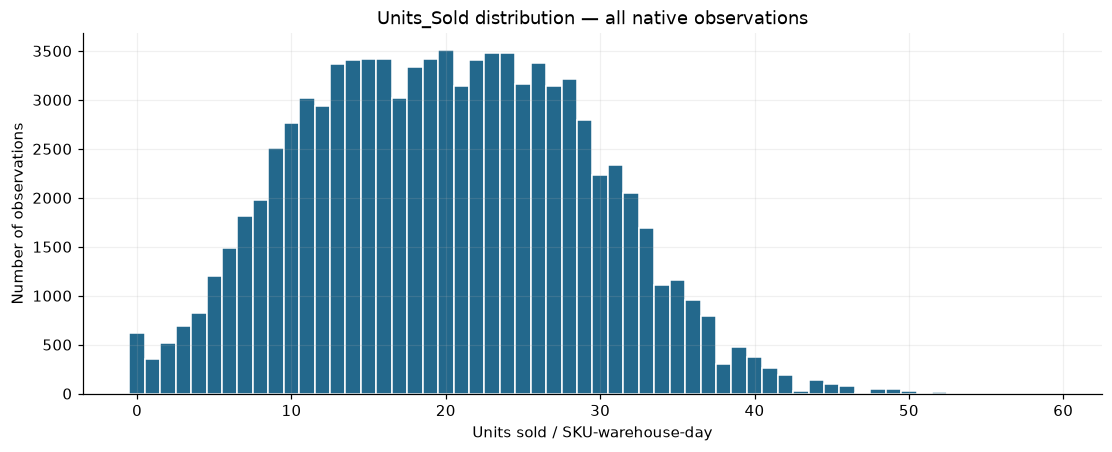

Total demand is 1,829,979 units. There are 620 zero-demand observations (0.679%). Native-series means range from 19.455 to 20.721 units; median coefficient of variation is 0.452184.

In [23]:
display(tables["distribution"])
display(tables["series"][["rows", "mean", "std", "zero_share", "coefficient_of_variation"]].describe())
show_and_save("demand-distribution")
display(Markdown(notes["overall"]))

### 2. Daily demand and descriptive smoothing

Daily totals aggregate all 250 series for visualization only; the native data remains unchanged. Daily means divide by the number of native observations. Rolling averages include the displayed day and require a full 7- or 14-day window. They are retrospective summaries, not forecasting features.

,Date,rows,total,mean,rolling_mean_7,rolling_mean_14
0,2024-01-01,250,5054,20.2160,NaN,NaN
1,2024-01-02,250,5072,20.2880,NaN,NaN
2,2024-01-03,250,5278,21.1120,NaN,NaN
3,2024-01-04,250,5144,20.5760,NaN,NaN
4,2024-01-05,250,5208,20.8320,NaN,NaN
5,2024-01-06,250,5178,20.7120,NaN,NaN
6,2024-01-07,250,5447,21.7880,"5,197.2857",NaN
7,2024-01-08,250,5322,21.2880,"5,235.5714",NaN
8,2024-01-09,250,5412,21.6480,"5,284.1429",NaN
9,2024-01-10,250,5464,21.8560,"5,310.7143",NaN


,total,mean,rolling_mean_7,rolling_mean_14
count,365.0000,365.0000,359.0000,352.0000
mean,"5,013.6411",20.0546,"5,013.1130","5,012.5580"
std,"1,818.4247",7.2737,"1,830.7500","1,845.1658"
min,"2,294.0000",9.1760,"2,394.1429","2,427.1429"
25%,"3,185.0000",12.7400,"3,159.2143","3,170.8393"
50%,"5,030.0000",20.1200,"5,033.8571","4,979.8571"
75%,"6,815.0000",27.2600,"6,835.4286","6,874.4107"
max,"7,702.0000",30.8080,"7,585.8571","7,576.5000"


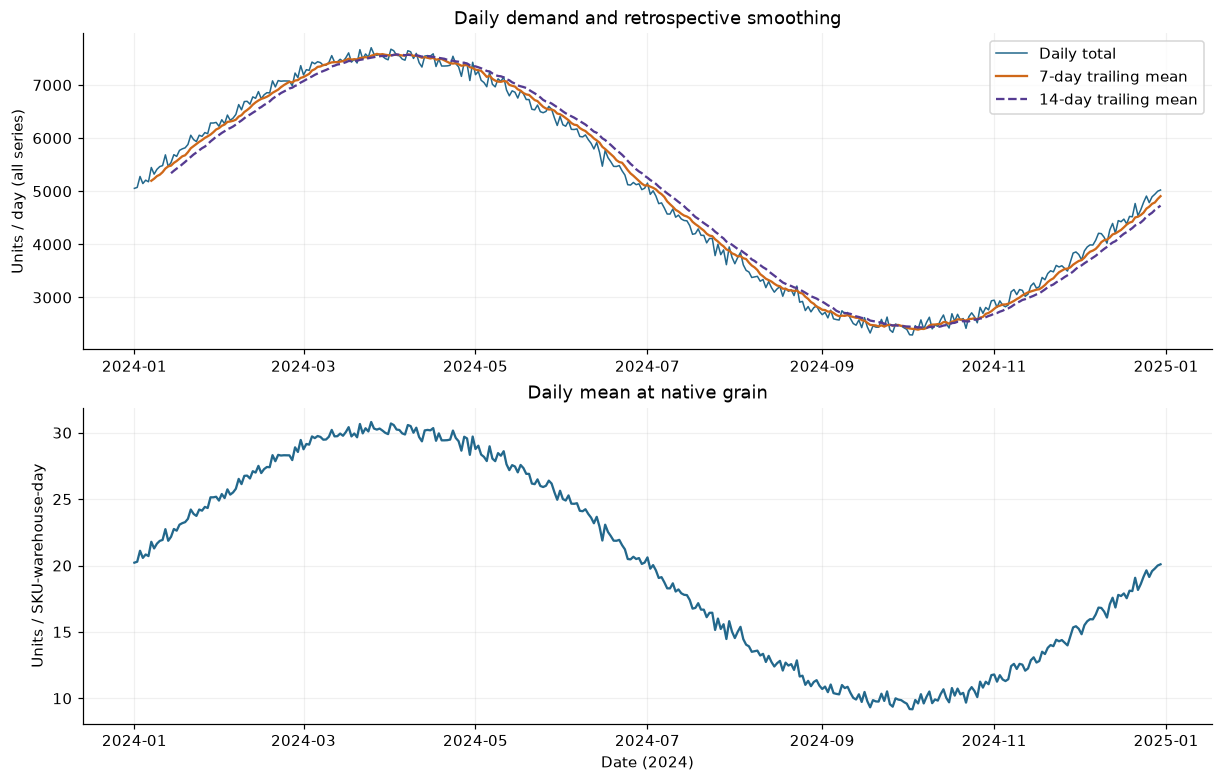

Trailing 7- and 14-day averages summarize the displayed day and preceding days. The first 6 and 13 outputs respectively are undefined because a full window is required. These retrospective EDA summaries are not forecasting features; smoothing alone is not evidence of predictive skill.

In [24]:
display(tables["daily"][["Date", "rows", "total", "mean", "rolling_mean_7", "rolling_mean_14"]].head(16))
display(tables["daily"][["total", "mean", "rolling_mean_7", "rolling_mean_14"]].describe())
show_and_save("daily-demand")
display(Markdown(notes["rolling"]))

### 3. Observed peaks, troughs and large daily changes

The five highest and lowest daily totals and ten largest absolute changes are ranked descriptive checks. They do not define statistical anomaly thresholds or justify deleting observations. Changes use the immediately preceding calendar day.

In [25]:
display(tables["extremes"][["kind", "Date", "total", "mean", "promotion_share"]])
display(tables["largest_changes"][["Date", "total", "change", "change_pct"]])
display(Markdown(notes["extremes"]))

,kind,Date,total,mean,promotion_share
0,highest daily totals,2024-03-25,7702,30.8080,0.1280
1,highest daily totals,2024-04-01,7674,30.6960,0.1120
2,highest daily totals,2024-03-21,7665,30.6600,0.0880
3,highest daily totals,2024-04-02,7645,30.5800,0.1360
4,highest daily totals,2024-04-07,7645,30.5800,0.1240
5,lowest daily totals,2024-10-03,2294,9.1760,0.0760
6,lowest daily totals,2024-10-02,2298,9.1920,0.1280
7,lowest daily totals,2024-09-18,2331,9.3240,0.1000
8,lowest daily totals,2024-09-26,2343,9.3720,0.0960
9,lowest daily totals,2024-09-25,2390,9.5600,0.0880


,Date,total,change,change_pct
6,2024-01-07,5447,269.0000,5.1951
119,2024-04-29,7084,-309.0000,-4.1796
120,2024-04-30,7428,344.0000,4.8560
126,2024-05-06,7244,277.0000,3.9759
167,2024-06-16,5769,298.0000,5.4469
206,2024-07-25,3788,-323.0000,-7.8570
210,2024-07-29,3617,-278.0000,-7.1374
211,2024-07-30,3952,335.0000,9.2618
236,2024-08-24,2911,-304.0000,-9.4557
300,2024-10-27,2814,291.0000,11.5339


The largest daily total is 7,702 on 2024-03-25; the smallest is 2,294 on 2024-10-03. The extreme tables rank observations, not statistical anomalies or records to remove. Large day-to-day moves are retained and have no inferred holiday explanation.

### 4. Monthly and within-year demand

Monthly totals depend on both demand level and number of observed dates. Monthly means use native observations; `mean_daily_total` uses observed days. Both month-to-month changes are shown. December has only 30 observed days; no extrapolation is applied.

,month,rows,days,total,mean,median,std,zero_share,promotion_share,calendar_days,mean_daily_total,total_change_pct,mean_change_pct
0,2024-01,7750,31,176681,22.7975,23.0000,5.7232,0.0000,0.1050,31,"5,699.3871",NaN,NaN
1,2024-02,7250,29,197188,27.1983,27.0000,5.7267,0.0000,0.0946,29,"6,799.5862",11.6068,19.3038
2,2024-03,7750,31,231596,29.8834,30.0000,5.8203,0.0000,0.1045,31,"7,470.8387",17.4493,9.8720
3,2024-04,7500,30,223793,29.8391,30.0000,5.7554,0.0000,0.1027,30,"7,459.7667",-3.3692,-0.1482
4,2024-05,7750,31,210841,27.2053,27.0000,5.7493,0.0000,0.1030,31,"6,801.3226",-5.7875,-8.8266
5,2024-06,7500,30,170013,22.6684,22.0000,5.7250,0.0000,0.0965,30,"5,667.1000",-19.3644,-16.6765
6,2024-07,7750,31,134915,17.4084,17.0000,5.5891,0.0008,0.1077,31,"4,352.0968",-20.6443,-23.2042
7,2024-08,7750,31,99019,12.7766,13.0000,5.3725,0.0120,0.1010,31,"3,194.1613",-26.6064,-26.6064
8,2024-09,7500,30,76304,10.1739,10.0000,5.0577,0.0280,0.0988,30,"2,543.4667",-22.9400,-20.3714
9,2024-10,7750,31,79599,10.2708,10.0000,5.1220,0.0319,0.1065,31,"2,567.7097",4.3183,0.9531


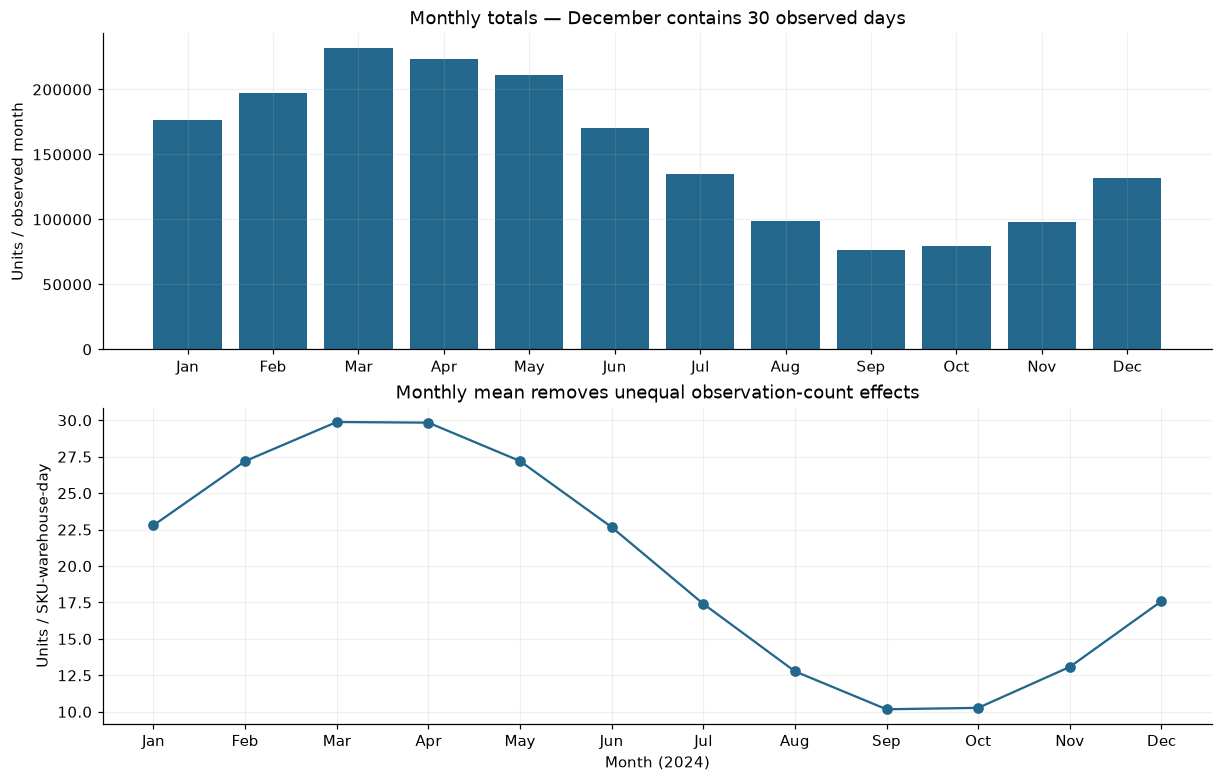

The highest monthly mean is 2024-03 (29.883 units per SKU-warehouse-day); the lowest is 2024-09 (10.174), a 2.94× ratio. Monthly totals reflect month length as well as demand level. These are observed within-year patterns, not evidence of recurring annual seasonality.

In [26]:
display(tables["monthly"])
show_and_save("monthly-demand")
display(Markdown(notes["monthly"]))

### 5. SKU-level monthly patterns

The heatmap shows all 50 SKU profiles. Each monthly native-observation mean is divided by that SKU's full-period mean (1 = its baseline). Normalization is for full-year descriptive comparison only. Pairwise profile correlations use the 12 monthly means, not raw series concatenated across warehouses.

,SKU_ID,month,rows,days,total,mean,median,std,zero_share,promotion_share,mean_index
0,SKU_1,2024-01,155,31,3549,22.8968,23.0000,5.5633,0.0000,0.1161,1.1286
1,SKU_1,2024-02,145,29,3887,26.8069,26.0000,5.4928,0.0000,0.0690,1.3213
2,SKU_1,2024-03,155,31,4618,29.7935,29.0000,5.3800,0.0000,0.1290,1.4685
3,SKU_1,2024-04,150,30,4579,30.5267,30.0000,5.5849,0.0000,0.0867,1.5046
4,SKU_1,2024-05,155,31,4231,27.2968,27.0000,5.5528,0.0000,0.0774,1.3454
5,SKU_1,2024-06,150,30,3459,23.0600,23.0000,5.3935,0.0000,0.0867,1.1366
6,SKU_1,2024-07,155,31,2813,18.1484,18.0000,5.6451,0.0000,0.1290,0.8945
7,SKU_1,2024-08,155,31,2021,13.0387,13.0000,5.5066,0.0129,0.0710,0.6427
8,SKU_1,2024-09,150,30,1577,10.5133,10.0000,5.2670,0.0133,0.1000,0.5182
9,SKU_1,2024-10,155,31,1600,10.3226,10.0000,4.5740,0.0323,0.0903,0.5088


,SKU_ID,min_month_mean,max_month_mean,max_min_ratio
count,50,50.0000,50.0000,50.0000
unique,50,NaN,NaN,NaN
top,SKU_1,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,10.0333,30.1298,3.0064
std,NaN,0.3337,0.3824,0.1106
min,NaN,9.4667,29.2000,2.7890
25%,NaN,9.7756,29.8581,2.9235
50%,NaN,10.0367,30.1355,3.0017
75%,NaN,10.3000,30.3129,3.0790


,statistic,pairwise_monthly_correlation
0,count,"1,225.0000"
1,mean,0.9969
2,std,0.0014
3,min,0.9903
4,25%,0.9962
5,50%,0.9972
6,75%,0.9979
7,max,0.9996


,month,SKUs_with_highest_mean
0,2024-03,29
1,2024-04,21


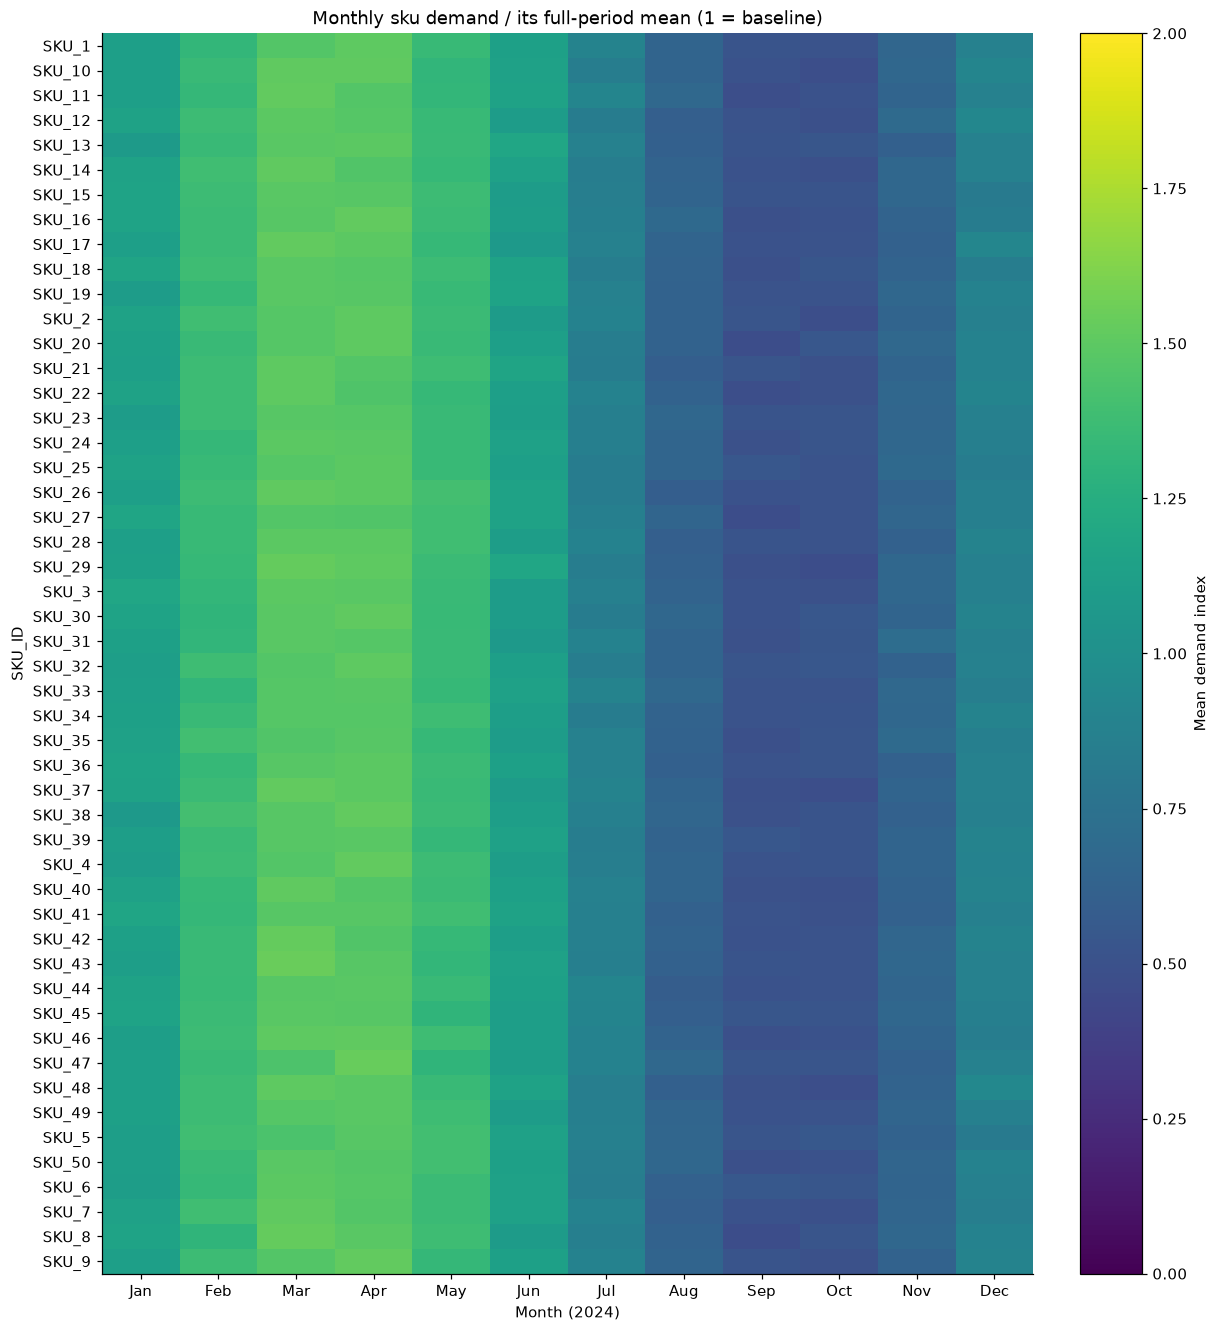

Across 50 skus, median pairwise correlation of the 12 monthly mean profiles is 0.997155 (minimum 0.990320). Within-sku highest/lowest monthly mean ratios range from 2.79 to 3.23. Broad temporal shapes are similar; this evidence does not suggest strongly distinct sku patterns at monthly resolution. Aggregation can conceal daily differences, and correlation does not establish equal levels or forecasting performance.

In [27]:
display(tables["sku_monthly"].head(12))
display(tables["sku_variation"].describe(include="all"))
display(tables["sku_pattern_similarity"])
sku_peaks = tables["sku_monthly"].loc[tables["sku_monthly"].groupby("SKU_ID")["mean"].idxmax()]
display(sku_peaks.groupby("month").size().reset_index(name="SKUs_with_highest_mean"))
show_and_save("sku-monthly-patterns")
display(Markdown(notes["sku"]))

### 6. Warehouse-level monthly patterns

Absolute means and normalized profiles answer different questions: magnitude versus shape. The full 5 × 12 monthly-mean table is shown alongside warehouse variation statistics.

Warehouse_ID,WH_1,WH_2,WH_3,WH_4,WH_5
month,,,,,
2024-01,22.8374,22.8019,22.6426,22.9845,22.7213
2024-02,27.1903,27.2076,27.1841,27.2800,27.1297
2024-03,29.9929,29.6561,30.0419,29.8768,29.8490
2024-04,29.6620,29.7587,29.9780,29.8633,29.9333
2024-05,27.1987,27.3510,27.3910,27.0071,27.0787
2024-06,22.7327,22.6487,22.7880,22.6380,22.5347
2024-07,17.5948,17.5045,17.4161,17.3090,17.2174
2024-08,12.8445,12.9348,12.5387,12.7406,12.8245
2024-09,10.3880,10.1940,10.0380,10.0267,10.2227


,Warehouse_ID,min_month_mean,max_month_mean,max_min_ratio
0,WH_1,10.1387,29.9929,2.9583
1,WH_2,10.1940,29.7587,2.9192
2,WH_3,10.0380,30.0419,2.9928
3,WH_4,10.0267,29.8768,2.9797
4,WH_5,10.2227,29.9333,2.9281


,statistic,pairwise_monthly_correlation
0,count,10.0000
1,mean,0.9998
2,std,0.0001
3,min,0.9997
4,25%,0.9997
5,50%,0.9998
6,75%,0.9998
7,max,0.9999


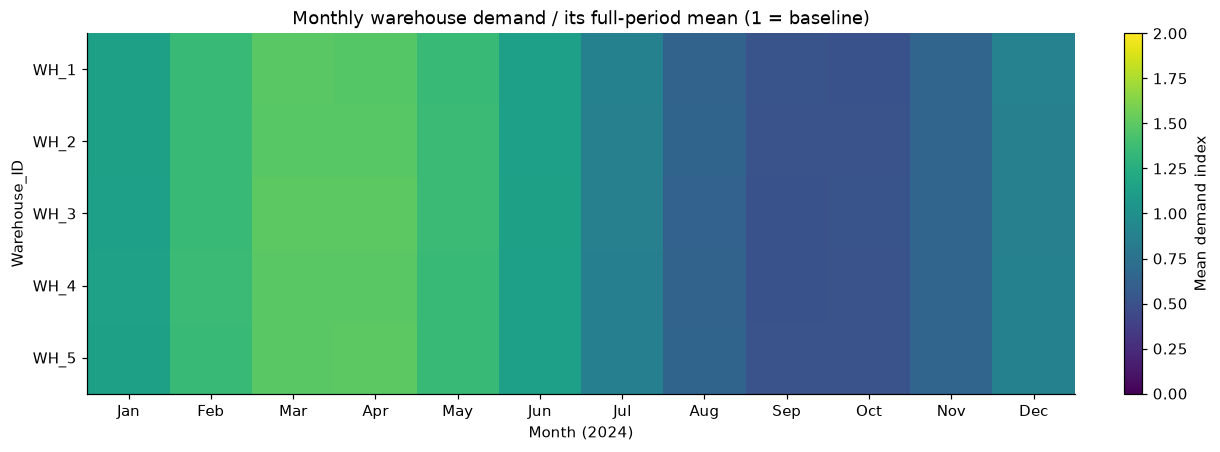

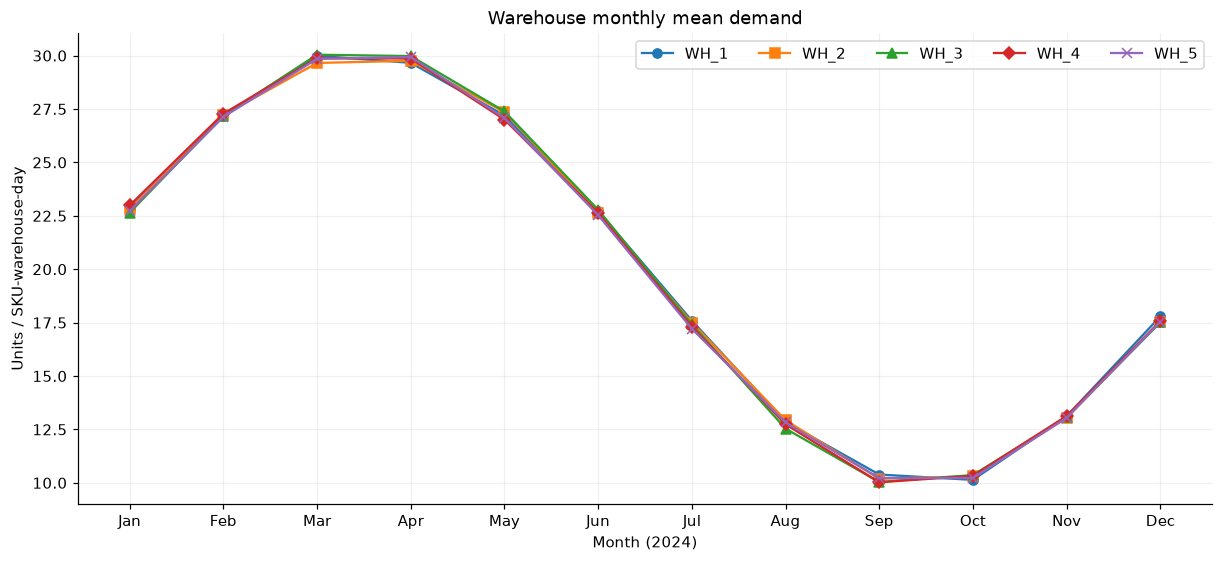

Across 5 warehouses, median pairwise correlation of the 12 monthly mean profiles is 0.999767 (minimum 0.999685). Within-warehouse highest/lowest monthly mean ratios range from 2.92 to 2.99. Broad temporal shapes are similar; this evidence does not suggest strongly distinct warehouse patterns at monthly resolution. Aggregation can conceal daily differences, and correlation does not establish equal levels or forecasting performance.

In [28]:
display(tables["warehouse_monthly"].pivot(index="month", columns="Warehouse_ID", values="mean"))
display(tables["warehouse_variation"])
display(tables["warehouse_pattern_similarity"])
show_and_save("warehouse-monthly-patterns")
show_and_save("warehouse-monthly-means")
display(Markdown(notes["warehouse"]))

### 7. Promotion relationship

The boxplots display medians, quartiles and 1.5-IQR whiskers; individual fliers are hidden for readability but remain in every calculation. Group counts, dispersion, and zero-demand frequency are shown. Within-month and within-series summaries help expose composition differences but do not establish causal effects.

,Promotion_Flag,rows,days,total,mean,median,std,zero_share,promotion_share
0,0,81980,365,1599018,19.5050,20.0000,8.6085,0.0067,0.0000
1,1,9270,365,230961,24.9149,24.0000,11.3085,0.0076,1.0000


,month,Promotion_Flag,rows,mean,std
0,2024-01,0,6936,22.1546,5.2372
1,2024-01,1,814,28.2764,6.6819
2,2024-02,0,6564,26.4712,5.1282
3,2024-02,1,686,34.1560,6.4453
4,2024-03,0,6940,29.0055,5.0144
5,2024-03,1,810,37.4049,6.7494
6,2024-04,0,6730,28.9936,5.0081
7,2024-04,1,770,37.2286,6.5285
8,2024-05,0,6952,26.4199,5.0577
9,2024-05,1,798,34.0476,6.7840


,promotion_minus_nonpromotion_mean
count,250.0000
mean,5.4422
std,2.0525
min,0.3620
25%,3.9931
50%,5.4382
75%,6.8095
max,13.5117


,comparable_series,positive_differences
0,250,250


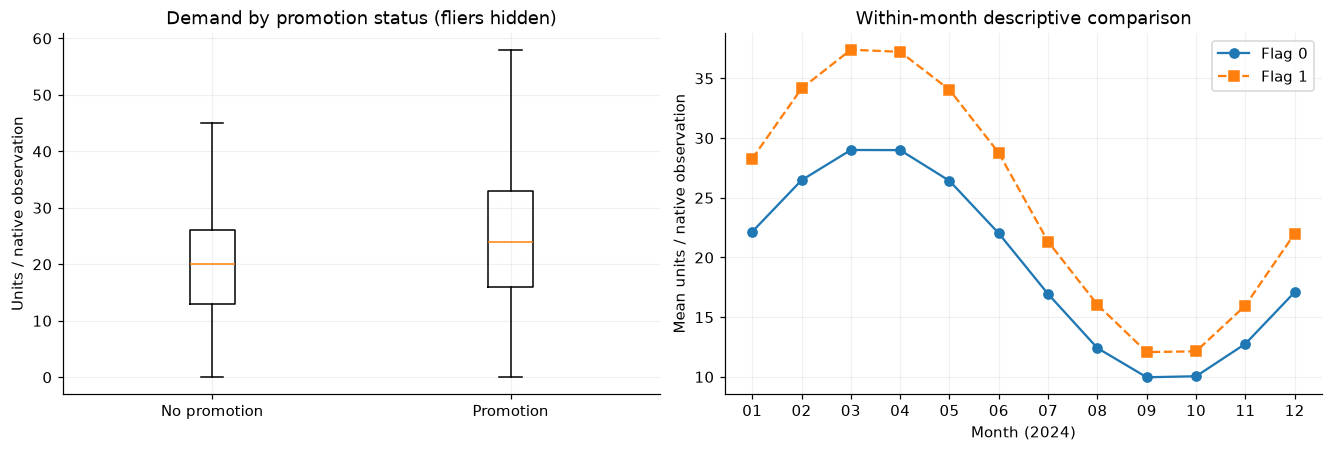

Promotion rows number 9,270, with mean demand 24.915; non-promotion rows number 81,980, with mean 19.505. The unadjusted difference is 5.410 units (27.74%). Monthly and within-series comparisons provide descriptive context, not causal identification or permission to use future promotion flags.

In [29]:
display(tables["promotion"])
display(tables["promotion_monthly"][["month", "Promotion_Flag", "rows", "mean", "std"]])
promotion_pairs = tables["promotion_series"].pivot(index=["SKU_ID", "Warehouse_ID"], columns="Promotion_Flag", values="mean")
promotion_difference = (promotion_pairs[1] - promotion_pairs[0]).rename("promotion_minus_nonpromotion_mean")
display(promotion_difference.describe().to_frame())
display(pd.DataFrame({"comparable_series": [promotion_difference.notna().sum()], "positive_differences": [promotion_difference.gt(0).sum()]}))
save_tables({"promotion_within_series_difference": promotion_difference.reset_index()}, LOCAL)
show_and_save("promotion-comparison")
display(Markdown(notes["promotion"]))

### 8. Short-lag dependence

Each Pearson correlation is calculated within one chronologically sorted SKU-warehouse series, aligned to calendar days. Lags 1, 7, 14 and 28 inspect existing candidates without selecting them. First differences are included as a sensitivity diagnostic for broad level movement, not a final data transformation. Constant or insufficient pairs produce undefined correlations, not zero.

,lag_days,defined_series,median,q25,q75,min,max,differenced_median
0,1,250,0.6401,0.6191,0.6593,0.5405,0.7091,-0.4991
1,7,250,0.6425,0.6178,0.6623,0.5513,0.7294,0.0030
2,14,250,0.6332,0.6140,0.6489,0.5528,0.7057,0.0103
3,28,250,0.5921,0.5748,0.6108,0.5041,0.6594,0.0015


,SKU_ID,Warehouse_ID,lag_days,correlation,differenced_correlation
0,SKU_1,WH_1,1,0.6306,-0.4877
1,SKU_1,WH_1,7,0.6379,0.0413
2,SKU_1,WH_1,14,0.5898,-0.0739
3,SKU_1,WH_1,28,0.5544,-0.0065
4,SKU_1,WH_2,1,0.6289,-0.5217
5,SKU_1,WH_2,7,0.6365,0.0065
6,SKU_1,WH_2,14,0.6162,-0.0357
7,SKU_1,WH_2,28,0.5937,0.0005
8,SKU_1,WH_3,1,0.6699,-0.5282
9,SKU_1,WH_3,7,0.6673,-0.0325


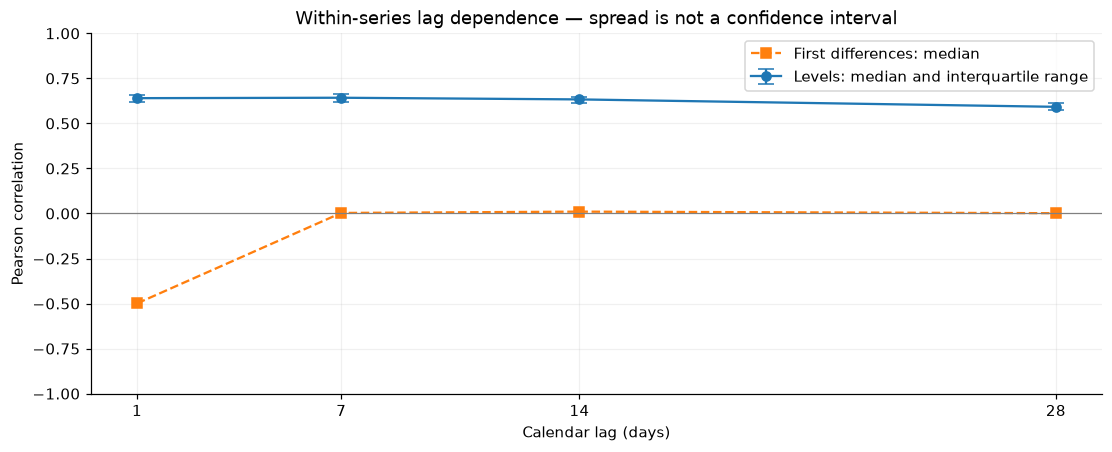

Median level correlations at lags 1, 7, 14 and 28 are 0.640, 0.642, 0.633 and 0.592. After first differencing, medians at lags 7, 14 and 28 are 0.003, 0.010 and 0.002. Broad level movement may contribute substantially to raw dependence; lag 7 is not uniquely elevated. Differencing is a diagnostic, not an approved preprocessing choice. Its negative lag-1 correlation can arise mechanically. No final lag set is selected.

In [30]:
display(tables["lag_summary"])
display(tables["lags"].head(12))
show_and_save("lag-dependence")
display(Markdown(notes["lags"]))

### 9. Evidence for future expanding-window validation

Calendar quarters summarize different portions of the observed year. They are descriptive bins, not selected folds or seasonal regimes. The standard deviation below describes native observations within each quarter, not uncertainty in a mean.

In [31]:
display(tables["quarterly"])
display(Markdown(notes["validation_design"]))

,quarter,rows,days,total,mean,median,std,zero_share,promotion_share
0,2024Q1,22750,91,605465,26.6138,26.0000,6.4698,0.0000,0.1015
1,2024Q2,22750,91,604647,26.5779,26.0000,6.4546,0.0000,0.1007
2,2024Q3,23000,92,310238,13.4886,13.0000,6.1255,0.0134,0.1026
3,2024Q4,22750,91,309629,13.6101,13.0000,6.1413,0.0137,0.1015


The monthly and quarterly summaries show differing demand levels across the observed year. Expanding-window evaluation origins spaced across the year could therefore test materially different demand levels and transitions, whereas adjacent origins could cover similar periods. This is evidence to consider, not proof of differing model performance. Later design must balance initial history, the approved 1-/7-/14-day horizons, available future outcomes, possible overlap between evaluation windows, and an untouched final holdout. Full-year EDA has already exposed broad future-period patterns, so this influence on validation design must be disclosed. No fold dates, final split, seasonal regimes or models are defined here.

## Takeaways and limitations

- Demand level differs across the year while broad monthly patterns are similar across SKUs and warehouses. This supports considering temporally spaced evaluation origins, subject to later approval.
- A single simulated year cannot prove recurring annual seasonality, holiday effects, real-world performance or causal promotion effects.
- Low zero-demand frequency is verified, but zero-variance `Stockout_Flag` cannot establish unconstrained demand or validate actual stockouts.
- Full-year exploration influences later design choices. Disclose that exposure and keep future model tuning separate from final holdout evaluation.
- No final train/validation/test dates, forecasting models, seasonal regimes or feature set are created.

### Reconciliation and report export

Totals are independently recomputed from the raw in-memory input. The report is generated from the same tables and interpretations used above. Detailed tables remain local; only aggregate figures and review outputs are embedded.

In [32]:
checks = {
    "daily totals equal source": tables["daily"].total.sum() == raw.Units_Sold.sum(),
    "monthly totals equal source": tables["monthly"].total.sum() == raw.Units_Sold.sum(),
    "SKU totals equal source": tables["sku_monthly"].total.sum() == raw.Units_Sold.sum(),
    "warehouse totals equal source": tables["warehouse_monthly"].total.sum() == raw.Units_Sold.sum(),
    "promotion counts equal source": tables["promotion"].rows.sum() == len(raw),
    "all figures saved": all((FIGURES / f"{name}.png").exists() for name in figures),
}
assert all(checks.values()), checks
display(pd.DataFrame({"check": checks.keys(), "passed": checks.values()}))
report = build_report(audit, tables, receipt)
(ROOT / "reports/demand-eda.md").write_text(report, encoding="utf-8")
display(Markdown("**Completed:** the report and PNG exports were regenerated from the displayed evidence. Save this executed notebook to retain all review outputs."))

,check,passed
0,daily totals equal source,True
1,monthly totals equal source,True
2,SKU totals equal source,True
3,warehouse totals equal source,True
4,promotion counts equal source,True
5,all figures saved,True


**Completed:** the report and PNG exports were regenerated from the displayed evidence. Save this executed notebook to retain all review outputs.